In [1]:
import os

os.chdir('..')

In [2]:
import os
import json
from collections import defaultdict
from nltk.translate.bleu_score import sentence_bleu
from rouge import Rouge
import numpy as np
import pandas as pd



def calculate_bleu(references, candidates):
    scores = [sentence_bleu([ref.split()], cand.split()) for ref, cand in zip(references, candidates)]
    return np.round(np.mean(scores) * 100, 1) if scores else 0

# Function to calculate ROUGE score
def calculate_rouge(references, candidates):
    rouge = Rouge()
    scores = rouge.get_scores(candidates, references, avg=True)
    rouge_1 = np.round(scores['rouge-1']['f'] * 100, 1)
    rouge_2 = np.round(scores['rouge-2']['f'] * 100, 1)
    rouge_l = np.round(scores['rouge-l']['f'] * 100, 1)
    return (rouge_1+rouge_2+rouge_l)/3

# Function to calculate Exact Match score
def calculate_em(references, candidates):
    references = [ref.split("\n\n")[0] for ref in references]
    em_scores = [1 if cal_correct(ref, cand) else 0 for ref, cand in zip(references, candidates)]
    return np.round(np.mean(em_scores) * 100, 1) if em_scores else 0

def cal_correct(generated_answer, expected_answer):
    is_correct = generated_answer.strip().lower().replace(".", "") == expected_answer.strip().lower().replace(".", "")
    return is_correct

In [3]:
import sys

import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from tqdm import tqdm
from peft import PeftModel
import json
import numpy as np
from datasets import load_dataset
from utils.prompter import Prompter
import torch
import torch.nn as nn
import torch.nn.functional as F

model_outputs_folder = "./performance_large/outputs/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_val_7b = {}

for file_name in os.listdir(model_outputs_folder):
    if file_name == '.DS_Store':
        continue

    if file_name.startswith("model_test") or file_name.startswith("degraded_model"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_val_7b[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_val_7b[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])
            if metric == 'rouge':
                model_output_dicts_val_7b[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])
            if metric == 'em':
                model_output_dicts_val_7b[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])

/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunc

In [4]:
import sys

import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from tqdm import tqdm
from peft import PeftModel
import json
import numpy as np
from datasets import load_dataset
from utils.prompter import Prompter
import torch
import torch.nn as nn
import torch.nn.functional as F

model_outputs_folder = "./performance_large/outputs/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_test_7b = {}

for file_name in os.listdir(model_outputs_folder):
    if not file_name.startswith("model_test"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_test_7b[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_test_7b[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])
            if metric == 'rouge':
                model_output_dicts_test_7b[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])
            if metric == 'em':
                model_output_dicts_test_7b[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])

In [5]:
import sys

import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from tqdm import tqdm
from peft import PeftModel
import json
import numpy as np
from datasets import load_dataset
from utils.prompter import Prompter
import torch
import torch.nn as nn
import torch.nn.functional as F

model_outputs_folder = "./performance_large/outputs_13b/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_val_13b = {}

for file_name in os.listdir(model_outputs_folder):
    if file_name == '.DS_Store':
        continue

    if file_name.startswith("model_test") or file_name.startswith("degraded_model"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_val_13b[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_val_13b[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])
            if metric == 'rouge':
                model_output_dicts_val_13b[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])
            if metric == 'em':
                model_output_dicts_val_13b[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])

In [6]:
model_outputs_folder = "./performance_large/outputs_13b/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_test_13b = {}

for file_name in os.listdir(model_outputs_folder):
    if not file_name.startswith("model_test"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_test_13b[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_test_13b[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])
            if metric == 'rouge':
                model_output_dicts_test_13b[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])
            if metric == 'em':
                model_output_dicts_test_13b[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])

In [7]:
data_path = "./dataset/config_large_flat.json"
if data_path.endswith(".json") or data_path.endswith(".jsonl"):
    dataset_val = load_dataset("json", data_files=data_path)
else:
    dataset_val = load_dataset(data_path)

dataset_val = dataset_val['train']

data_path = './dataset/combined_test.json'
data_path = "./dataset/combined_test.json"
if data_path.endswith(".json") or data_path.endswith(".jsonl"):
    dataset_test = load_dataset("json", data_files=data_path)
else:
    dataset_test = load_dataset(data_path)

dataset_test = dataset_test['train']

In [8]:
max_score_per_sample_7b = {}
max_score_per_sample_13b = {}
for sample in dataset_val:
    max_score_per_sample_7b[sample['inputs']] = 0.0
    max_score_per_sample_13b[sample['inputs']] = 0.0
    for i in range(48):
        model_index = model_names[i]
        max_score_per_sample_7b[sample['inputs']] = max(max_score_per_sample_7b[sample['inputs']], model_output_dicts_val_7b[model_index][sample['inputs']])
        max_score_per_sample_13b[sample['inputs']] = max(max_score_per_sample_13b[sample['inputs']], model_output_dicts_val_13b[model_index][sample['inputs']])

In [9]:
# Load embeddings
validation_embeddings = np.load('test_results/validation_embeddings_bge.npy')
test_embeddings = np.load('test_results/test_embeddings_bge.npy')

print(f"Validation embeddings shape: {validation_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Validation embeddings shape: (8760, 1024)
Test embeddings shape: (2395, 1024)


In [10]:
baseline_results_7b = {}
baseline_results_13b = {}

for model_id in range(48):
    model_results_7b = {}
    model_results_13b = {}
    for sample in dataset_test:
        if sample['task'] not in model_results_7b:
            model_results_7b[sample['task']] = []
            model_results_13b[sample['task']] = []
        model_results_7b[sample['task']].append(model_output_dicts_test_7b[model_names[model_id]][sample['inputs']])
        model_results_13b[sample['task']].append(model_output_dicts_test_13b[model_names[model_id]][sample['inputs']])
    
    for task in model_results_7b:
        if task not in baseline_results_7b:
            baseline_results_7b[task] = 0.0
            baseline_results_13b[task] = 0.0
        baseline_results_7b[task] = max(baseline_results_7b[task], np.mean(model_results_7b[task]))
        baseline_results_13b[task] = max(baseline_results_13b[task], np.mean(model_results_13b[task]))

In [11]:
norm_by_domain_7b = {
    'struct to text': (63.5 + 39.0 + 56.6) / 3,  # Average of rouge-1, rouge-2, rouge-l
    'commonsense': 63.0,
    'sentiment': 90.0,
    'reading comp': 67.7,
    'closed_book QA': 44.0,
    'coreference': 51.0,
    'read.comp.w:commonsense': 70.0,
    'paraphrase': 63.5,
    'nli': 73.1,
    'translation': 13.1
}

norm_by_domain_13b = {
    'struct to text': (65.0 + 40.4 + 58.3) / 3,  # Average of rouge-1, rouge-2, rouge-l
    'commonsense': 69.0,
    'sentiment': 90.0,
    'reading comp': 76.3,
    'closed_book QA': 65.0,
    'coreference': 75.0,
    'read.comp.w:commonsense': 81.0,
    'paraphrase': 76.5,
    'nli': 82.0,
    'translation': 12.8
}

domains = list(norm_by_domain_7b.keys())

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import hashlib
import json

def cluster_embeddings_kmeans(embeddings, dataset_val, n_clusters, random_state=42):
    """
    Cluster embeddings using K-Means algorithm with cosine similarity.
    Results are cached in a local JSON file based on input parameters.
    
    Parameters:
    -----------
    embeddings : np.ndarray
        Array of shape (n_samples, embedding_dim) containing the embeddings
    n_clusters : int
        The number of clusters to form
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    labels : np.ndarray
        Cluster labels for each sample (0 to n_clusters-1)
    n_clusters : int
        Number of clusters (same as input parameter)
    cluster_embeddings : np.ndarray
        Average embeddings for each cluster (shape: n_clusters x embedding_dim)
    """
    # Create cache directory if it doesn't exist
    cache_dir = "kmeans_results/cluster_cache"
    os.makedirs(cache_dir, exist_ok=True)
    
    # Create a unique cache key based on input parameters
    embeddings_hash = hashlib.md5(embeddings.tobytes()).hexdigest()[:16]
    cache_key = f"kmeans_n{n_clusters}_rs{random_state}_h{embeddings_hash}"
    cache_file = os.path.join(cache_dir, f"{cache_key}.json")
    
    # Try to load from cache
    if os.path.exists(cache_file):
        with open(cache_file, 'r') as f:
            cached_data = json.load(f)
        cluster_embeddings = np.array(cached_data['cluster_embeddings'])
        model_performance_7b = np.array(cached_data['model_performance_7b'])
        model_performance_13b = np.array(cached_data['model_performance_13b'])
        return cluster_embeddings, model_performance_7b, model_performance_13b
    
    # Normalize embeddings for cosine similarity-based clustering
    normalized_embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    
    # Perform K-Means clustering with parallel processing
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = kmeans.fit_predict(normalized_embeddings)
    
    # Compute cluster embeddings by averaging original embeddings in each cluster
    cluster_embeddings = np.zeros((n_clusters, embeddings.shape[1]))
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        if np.any(cluster_mask):
            cluster_embeddings[cluster_id] = embeddings[cluster_mask].mean(axis=0)

    model_performance_7b = np.zeros((n_clusters, 48))
    model_performance_13b = np.zeros((n_clusters, 48))
    for id, sample in enumerate(dataset_val):
        cluster_id = labels[id]
        if max_score_per_sample_7b[sample['inputs']]==0.0:
            continue
        for i in range(48):
            model_index = model_names[i]
            model_performance_7b[cluster_id][i] += model_output_dicts_val_7b[model_index][sample['inputs']]/norm_by_domain_7b[sample['domain']]

    for id, sample in enumerate(dataset_val):
        cluster_id = labels[id]
        if max_score_per_sample_13b[sample['inputs']]==0.0:
            continue
        for i in range(48):
            model_index = model_names[i]
            model_performance_13b[cluster_id][i] += model_output_dicts_val_13b[model_index][sample['inputs']]/norm_by_domain_13b[sample['domain']]
    
    # Save to cache
    cache_data = {
        'cluster_embeddings': cluster_embeddings.tolist(),
        'model_performance_7b': model_performance_7b.tolist(),
        'model_performance_13b': model_performance_13b.tolist(),
        'n_clusters': n_clusters,
        'random_state': random_state
    }
    with open(cache_file, 'w') as f:
        json.dump(cache_data, f)
    
    return cluster_embeddings, model_performance_7b, model_performance_13b

In [13]:
def evalute_clusters(k, dataset_val=dataset_val):
    cluster_embeddings, model_performance_7b, model_performance_13b = cluster_embeddings_kmeans(validation_embeddings, dataset_val, k)
    results_by_domain_7b = {}
    results_by_domain_13b = {}
    for id, sample in enumerate(dataset_test):
        domain = sample['domain']
        task = sample['task']
        if domain not in results_by_domain_7b:
            results_by_domain_7b[domain] = []
            results_by_domain_13b[domain] = []
        
        I = test_embeddings[id,:]
        I_norm = I / (np.linalg.norm(I) + 1e-8)  # Normalize input embedding
        A_norm = cluster_embeddings / (np.linalg.norm(cluster_embeddings, axis=1, keepdims=True) + 1e-8)  # Normalize cluster embeddings
        logits = I_norm @ A_norm.T  # Cosine similarity
        selected_task = logits.argmax()

        selected_model = model_performance_7b[selected_task,:].argmax()
        model_index = model_names[selected_model]
        results_by_domain_7b[domain].append(model_output_dicts_test_7b[model_index][sample['inputs']]/norm_by_domain_7b[domain])

        selected_model = model_performance_13b[selected_task,:].argmax()
        model_index = model_names[selected_model]
        results_by_domain_13b[domain].append(model_output_dicts_test_13b[model_index][sample['inputs']]/norm_by_domain_13b[domain])
        
    total_score_7b = 0.0
    total_score_13b = 0.0

    for i, domain in enumerate(results_by_domain_7b.keys()):
        results_by_domain_7b[domain] = np.array(results_by_domain_7b[domain]).mean()
        total_score_7b += results_by_domain_7b[domain]/len(results_by_domain_7b.keys())

    for i, domain in enumerate(results_by_domain_13b.keys()):
        results_by_domain_13b[domain] = np.array(results_by_domain_13b[domain]).mean()
        total_score_13b += results_by_domain_13b[domain]/len(results_by_domain_13b.keys())
    
    return results_by_domain_7b, total_score_7b, results_by_domain_13b, total_score_13b

In [ ]:
results_7b = []
results_13b = []

for p in range(9):
    _, total_score_7b, _, total_score_13b = evalute_clusters(k=6*pow(2,p))
    results_7b.append(total_score_7b)
    results_13b.append(total_score_13b)
    print(f"K: {6*pow(2,p)} 7b score: ", total_score_7b)
    print(f"K: {6*pow(2,p)} 13b score: ", total_score_13b)

K: 6 7b score:  0.8576889972816366
K: 6 13b score:  0.8278840768953418
K: 12 7b score:  0.8585302411590809
K: 12 13b score:  0.8365962531869426
K: 24 7b score:  0.8943144209212842
K: 24 13b score:  0.8746761958653227
K: 48 7b score:  0.9759392901183889
K: 48 13b score:  0.940867859301734
K: 96 7b score:  0.9775562979193918
K: 96 13b score:  0.9224192622315288
K: 192 7b score:  0.9451809060994204
K: 192 13b score:  0.9161528139720512
K: 384 7b score:  0.9401455715051574
K: 384 13b score:  0.9117528890024977


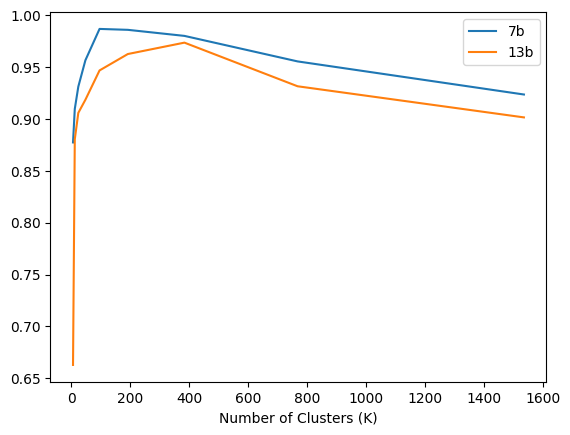

In [ ]:
import matplotlib.pyplot as plt
plt.plot([6*pow(2,p) for p in range(9)], results_7b, label='7b')
plt.plot([6*pow(2,p) for p in range(9)], results_13b, label='13b')
plt.xlabel('Number of Clusters (K)')
plt.legend()

In [ ]:
def cluster_embeddings_kmeans_ood(embeddings, exclude_model, dataset_val, n_clusters=10):
    filtered_embeddings = []
    filtered_dataset = []
    for id, sample in enumerate(dataset_val):
        if sample['model_name'] == exclude_model:
            continue
        filtered_dataset.append(sample)
        filtered_embeddings.append(embeddings[id,:])
    filtered_embeddings = np.array(filtered_embeddings)
    
    return cluster_embeddings_kmeans(filtered_embeddings, filtered_dataset, n_clusters)

In [ ]:
def evalute_clusters_ood(k=None, dataset_val=dataset_val):
    all_cluster_embeddings = []
    all_model_performance_7b = []
    all_model_performance_13b = []
    for id, model in enumerate(model_names):
        cluster_embeddings, model_performance_7b, model_performance_13b = cluster_embeddings_kmeans_ood(validation_embeddings, model, dataset_val, k)
        model_performance_7b[:,id] = -1.0
        model_performance_13b[:,id] = -1.0
        all_cluster_embeddings.append(cluster_embeddings)
        all_model_performance_7b.append(model_performance_7b)
        all_model_performance_13b.append(model_performance_13b)
    
    results_by_domain_7b = {}
    results_by_domain_13b = {}

    for id, sample in enumerate(dataset_test):
        domain = sample['domain']
        task = sample['task']
        if domain not in results_by_domain_7b:
            results_by_domain_7b[domain] = []
            results_by_domain_13b[domain] = []

        model_id = model_names.index(sample['task'])
        model_performance_7b = all_model_performance_7b[model_id]
        model_performance_13b = all_model_performance_13b[model_id]
        cluster_embeddings = all_cluster_embeddings[model_id]
        
        I = test_embeddings[id,:]
        I_norm = I / (np.linalg.norm(I) + 1e-8)  # Normalize input embedding
        A_norm = cluster_embeddings / (np.linalg.norm(cluster_embeddings, axis=1, keepdims=True) + 1e-8)  # Normalize cluster embeddings
        logits = I_norm @ A_norm.T  # Cosine similarity
        selected_task = logits.argmax()

        selected_model = model_performance_7b[selected_task,:].argmax()
        model_index = model_names[selected_model]
        results_by_domain_7b[domain].append(model_output_dicts_test_7b[model_index][sample['inputs']]/norm_by_domain_7b[domain])

        selected_model = model_performance_13b[selected_task,:].argmax()
        model_index = model_names[selected_model]
        results_by_domain_13b[domain].append(model_output_dicts_test_13b[model_index][sample['inputs']]/norm_by_domain_13b[domain])
    total_score_7b = 0.0

    for i, domain in enumerate(results_by_domain_7b.keys()):
        results_by_domain_7b[domain] = np.array(results_by_domain_7b[domain]).mean()
        total_score_7b += results_by_domain_7b[domain]/len(results_by_domain_7b.keys())
    
    total_score_13b = 0.0
    for i, domain in enumerate(results_by_domain_13b.keys()):
        results_by_domain_13b[domain] = np.array(results_by_domain_13b[domain]).mean()
        total_score_13b += results_by_domain_13b[domain]/len(results_by_domain_13b.keys())
    
    return results_by_domain_7b, results_by_domain_13b, total_score_7b, total_score_13b

In [ ]:
results_ood_7b = []
results_ood_13b = []
for p in range(9):
    _, _, total_score_7b, total_score_13b = evalute_clusters_ood(6*pow(2,p))
    results_ood_7b.append(total_score_7b)
    results_ood_13b.append(total_score_13b)
    print(f"K: {6*pow(2,p)} 7b OOD score: ", total_score_7b)
    print(f"K: {6*pow(2,p)} 13b OOD score: ", total_score_13b)

K: 6 7b OOD score:  0.7871839814512687
K: 6 13b OOD score:  0.784114031012454
K: 12 7b OOD score:  0.8510158240891517
K: 12 13b OOD score:  0.8167633674911232
K: 24 7b OOD score:  0.8133859592999207
K: 24 13b OOD score:  0.7900787578398633
K: 48 7b OOD score:  0.7772750845812559
K: 48 13b OOD score:  0.7560656701299056
K: 96 7b OOD score:  0.7741345783112681
K: 96 13b OOD score:  0.7495072049161545
K: 192 7b OOD score:  0.7779344341953546
K: 192 13b OOD score:  0.7748014448669155
K: 384 7b OOD score:  0.7289086188254886
K: 384 13b OOD score:  0.7587005225809051
K: 768 7b OOD score:  0.7201495171948393
K: 768 13b OOD score:  0.7312980982811483
K: 1536 7b OOD score:  0.7058306085853102
K: 1536 13b OOD score:  0.7082505530210039


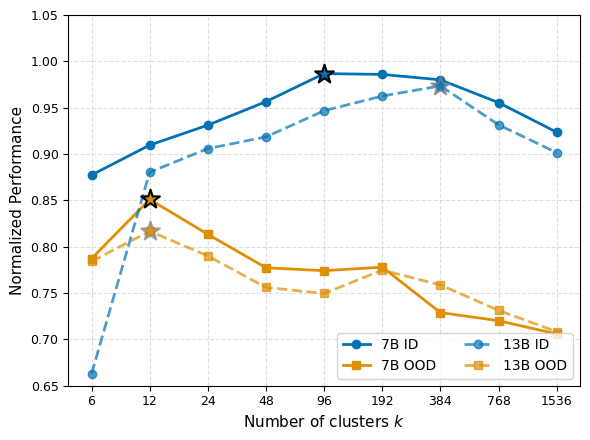

7B - Optimal k (ID): 96, Score: 0.9868
7B - Optimal k (OOD): 12, Score: 0.8510
13B - Optimal k (ID): 384, Score: 0.9735
13B - Optimal k (OOD): 12, Score: 0.8168


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x_values = [6, 12, 24, 48, 96, 192, 384, 768, 1536]
x_values = np.array([6*pow(2,p) for p in range(9)])

# Create single plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Color scheme - colorblind friendly
color_id = '#0173B2'  # Blue for ID
color_ood = '#DE8F05'  # Orange for OOD

# Plot 7B model (solid lines)
ax.semilogx(x_values, results_7b, marker='o', base=2, label="7B ID", 
            color=color_id, linewidth=2, markersize=6, linestyle='-')
ax.semilogx(x_values, results_ood_7b, marker='s', base=2, label="7B OOD", 
            color=color_ood, linewidth=2, markersize=6, linestyle='-')

# Plot 13B model (dashed lines)
ax.semilogx(x_values, results_13b, marker='o', base=2, label="13B ID", 
            color=color_id, linewidth=2, markersize=6, linestyle='--', alpha=0.7)
ax.semilogx(x_values, results_ood_13b, marker='s', base=2, label="13B OOD", 
            color=color_ood, linewidth=2, markersize=6, linestyle='--', alpha=0.7)

# Mark maximum points for 7B
max_idx_7b = np.argmax(results_7b)
max_idx_ood_7b = np.argmax(results_ood_7b)
ax.scatter(x_values[max_idx_7b], results_7b[max_idx_7b],
           s=200, marker='*', color=color_id, edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(x_values[max_idx_ood_7b], results_ood_7b[max_idx_ood_7b],
           s=200, marker='*', color=color_ood, edgecolor='black', linewidth=1.5, zorder=5)

# Mark maximum points for 13B
max_idx_13b = np.argmax(results_13b)
max_idx_ood_13b = np.argmax(results_ood_13b)
ax.scatter(x_values[max_idx_13b], results_13b[max_idx_13b],
           s=200, marker='*', color=color_id, edgecolor='gray', linewidth=1.5, zorder=5, alpha=0.7)
ax.scatter(x_values[max_idx_ood_13b], results_ood_13b[max_idx_ood_13b],
           s=200, marker='*', color=color_ood, edgecolor='gray', linewidth=1.5, zorder=5, alpha=0.7)

ax.set_xticks(x_values)
ax.set_xticklabels([str(k) for k in x_values], fontsize=9)
ax.set_xlabel("Number of clusters $k$", fontsize=11)
ax.set_ylabel("Normalized Performance", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4, which='both')
ax.legend(loc='lower right', frameon=True, fontsize=10, ncol=2)
ax.tick_params(axis='y', labelsize=9)
ax.set_ylim(0.65,1.05)

plt.tight_layout()
plt.savefig('cluster_size_comparison_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"7B - Optimal k (ID): {x_values[max_idx_7b]}, Score: {results_7b[max_idx_7b]:.4f}")
print(f"7B - Optimal k (OOD): {x_values[max_idx_ood_7b]}, Score: {results_ood_7b[max_idx_ood_7b]:.4f}")
print(f"13B - Optimal k (ID): {x_values[max_idx_13b]}, Score: {results_13b[max_idx_13b]:.4f}")
print(f"13B - Optimal k (OOD): {x_values[max_idx_ood_13b]}, Score: {results_ood_13b[max_idx_ood_13b]:.4f}")

In [ ]:
# Function to process a file
def process_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)

    organized_data = defaultdict(lambda: defaultdict(list))
    for entry in data:
        domain = entry['domain']
        #domain = entry['task']
        task = entry['task']
        organized_data[domain][task].append(entry)
    
    return organized_data

# Function to process all files in a folder and aggregate scores by domain and metric
def get_results(file_path):
    domain_specific_metrics = defaultdict(list)
    domains_data = process_file(file_path)

    if file_path.endswith('7b.json'):
        norm_by_domain = norm_by_domain_7b
    else:
        norm_by_domain = norm_by_domain_13b

    for domain, tasks_data in domains_data.items():
        for task, entries in tasks_data.items():
            metric = entries[0]['metric']
            references = [entry['targets'] for entry in entries]
            candidates = [entry['predicted_answer'] for entry in entries]

            if metric == 'bleu':
                score = calculate_bleu(references, candidates)/norm_by_domain[domain]
                domain_specific_metrics[domain].append(score)
            elif metric == 'rouge':
                score = calculate_rouge(references, candidates)/norm_by_domain[domain]
                domain_specific_metrics[domain].append(score)
            elif metric == 'em':
                score = calculate_em(references, candidates)/norm_by_domain[domain]
                domain_specific_metrics[domain].append(score)

    result = 0.0
    for domain, tasks_data in domains_data.items():
        result += np.array(domain_specific_metrics[domain]).mean()/len(domains_data)
    return result

In [ ]:
final_results_13b = get_results('./final_results/perf_fusion_13b.json')
final_results_7b = get_results('./final_results/perf_fusion_7b.json')
final_results_7b_ood = get_results('./final_results/perf_fusion_ood_7b.json')
final_results_13b_ood = get_results('./final_results/perf_fusion_ood_13b.json')

print(f"Final Fusion 7B ID Score: {final_results_7b:.4f}")
print(f"Final Fusion 13B ID Score: {final_results_13b:.4f}")
print(f"Final Fusion 7B OOD Score: {final_results_7b_ood:.4f}")
print(f"Final Fusion 13B OOD Score: {final_results_13b_ood:.4f}")

Final Fusion 7B ID Score: 1.0121
Final Fusion 13B ID Score: 0.9884
Final Fusion 7B OOD Score: 0.8842
Final Fusion 13B OOD Score: 0.8685


/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunc

In [ ]:
results_fusion_7b = []
results_fusion_13b = []
results_fusion_ood_7b = []
results_fusion_ood_13b = []

for p in range(9):
    k = 6*pow(2,p)
    file_path_7b = f'./kmeans_results/fusion_{k}_7b.json'
    file_path_13b = f'./kmeans_results/fusion_{k}_13b.json'
    file_path_ood_7b = f'./kmeans_results/fusion_ood_{k}_7b.json'
    file_path_ood_13b = f'./kmeans_results/fusion_ood_{k}_13b.json'

    results_7b = get_results(file_path_7b)
    results_13b = get_results(file_path_13b)
    results_ood_7b = get_results(file_path_ood_7b)
    results_ood_13b = get_results(file_path_ood_13b)

    results_fusion_7b.append(results_7b)
    results_fusion_13b.append(results_13b)
    results_fusion_ood_7b.append(results_ood_7b)
    results_fusion_ood_13b.append(results_ood_13b)
    
    print(f"Fusion K: {k} 7b score: ", results_7b)
    print(f"Fusion K: {k} 7b OOD score: ", results_ood_7b)
    print(f"Fusion K: {k} 13b score: ", results_13b)
    print(f"Fusion K: {k} 13b OOD score: ", results_ood_13b)

Fusion K: 6 7b score:  0.898361113987576
Fusion K: 6 7b OOD score:  0.8334046926866318
Fusion K: 6 13b score:  0.5886503937032169
Fusion K: 6 13b OOD score:  0.8159192522873114
Fusion K: 12 7b score:  0.9298739732794451
Fusion K: 12 7b OOD score:  0.8590530074951273
Fusion K: 12 13b score:  0.9089696841393076
Fusion K: 12 13b OOD score:  0.844044554407342
Fusion K: 24 7b score:  0.9359267220141725
Fusion K: 24 7b OOD score:  0.879842635902912
Fusion K: 24 13b score:  0.9446907320830169
Fusion K: 24 13b OOD score:  0.8566610997604666
Fusion K: 48 7b score:  0.9668370655154774
Fusion K: 48 7b OOD score:  0.8801238852027827
Fusion K: 48 13b score:  0.9328295589431117
Fusion K: 48 13b OOD score:  0.8596781704489658
Fusion K: 96 7b score:  1.0149479201850617
Fusion K: 96 7b OOD score:  0.857703844494664
Fusion K: 96 13b score:  0.976301728164906
Fusion K: 96 13b OOD score:  0.8611409585136421
Fusion K: 192 7b score:  0.9998995655809293
Fusion K: 192 7b OOD score:  0.867833347924565
Fusion K

FileNotFoundError: [Errno 2] No such file or directory: './kmeans_results/fusion_768_7b.json'

IndexError: invalid index to scalar variable.

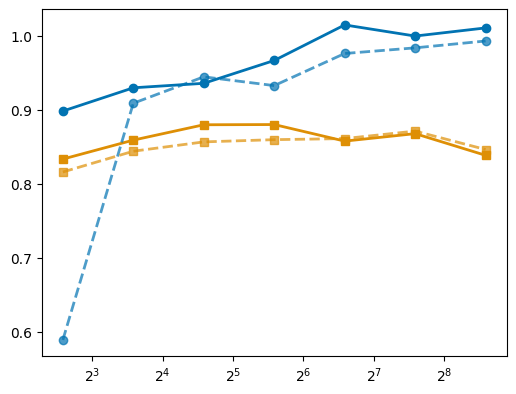

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x_values = [6, 12, 24, 48, 96, 192, 384, 768, 1536]
x_values = np.array([6*pow(2,p) for p in range(7)])

# Create single plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Color scheme - colorblind friendly
color_id = '#0173B2'  # Blue for ID
color_ood = '#DE8F05'  # Orange for OOD

# Plot 7B model (solid lines)
ax.semilogx(x_values, results_fusion_7b, marker='o', base=2, label="7B ID", 
            color=color_id, linewidth=2, markersize=6, linestyle='-')
ax.semilogx(x_values, results_fusion_ood_7b, marker='s', base=2, label="7B OOD", 
            color=color_ood, linewidth=2, markersize=6, linestyle='-')

# Plot 13B model (dashed lines)
ax.semilogx(x_values, results_fusion_13b, marker='o', base=2, label="13B ID", 
            color=color_id, linewidth=2, markersize=6, linestyle='--', alpha=0.7)
ax.semilogx(x_values, results_fusion_ood_13b, marker='s', base=2, label="13B OOD", 
            color=color_ood, linewidth=2, markersize=6, linestyle='--', alpha=0.7)

# Mark maximum points for 7B
max_idx_7b = np.argmax(results_fusion_7b)
max_idx_ood_7b = np.argmax(results_fusion_ood_7b)
ax.scatter(x_values[max_idx_7b], results_7b[max_idx_7b],
           s=200, marker='*', color=color_id, edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(x_values[max_idx_ood_7b], results_ood_7b[max_idx_ood_7b],
           s=200, marker='*', color=color_ood, edgecolor='black', linewidth=1.5, zorder=5)

# Mark maximum points for 13B
max_idx_13b = np.argmax(results_fusion_13b)
max_idx_ood_13b = np.argmax(results_fusion_ood_13b)
ax.scatter(x_values[max_idx_13b], results_fusion_13b[max_idx_13b],
           s=200, marker='*', color=color_id, edgecolor='gray', linewidth=1.5, zorder=5, alpha=0.7)
ax.scatter(x_values[max_idx_ood_13b], results_fusion_ood_13b[max_idx_ood_13b],
           s=200, marker='*', color=color_ood, edgecolor='gray', linewidth=1.5, zorder=5, alpha=0.7)

ax.set_xticks(x_values)
ax.set_xticklabels([str(k) for k in x_values], fontsize=9)
ax.set_xlabel("Number of clusters $k$", fontsize=11)
ax.set_ylabel("Normalized Performance", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4, which='both')
ax.legend(loc='lower right', frameon=True, fontsize=10, ncol=2)
ax.tick_params(axis='y', labelsize=9)
ax.set_ylim(0.65,1.05)

plt.tight_layout()
plt.savefig('cluster_size_comparison_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"7B - Optimal k (ID): {x_values[max_idx_7b]}, Score: {results_7b[max_idx_7b]:.4f}")
print(f"7B - Optimal k (OOD): {x_values[max_idx_ood_7b]}, Score: {results_ood_7b[max_idx_ood_7b]:.4f}")
print(f"13B - Optimal k (ID): {x_values[max_idx_13b]}, Score: {results_13b[max_idx_13b]:.4f}")
print(f"13B - Optimal k (OOD): {x_values[max_idx_ood_13b]}, Score: {results_ood_13b[max_idx_ood_13b]:.4f}")